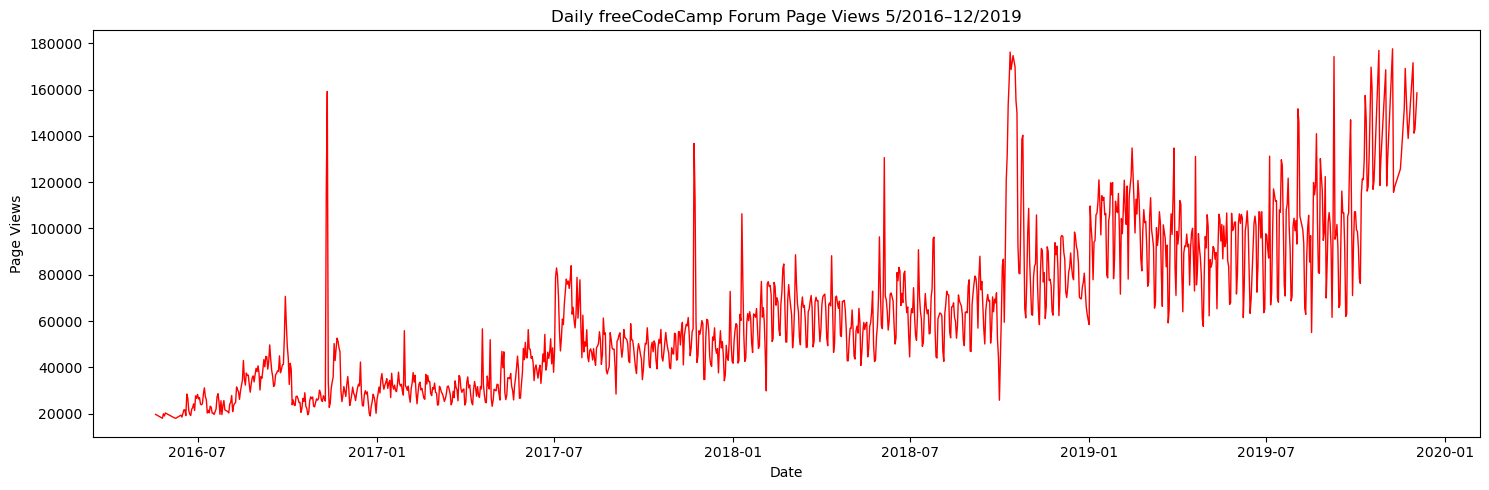

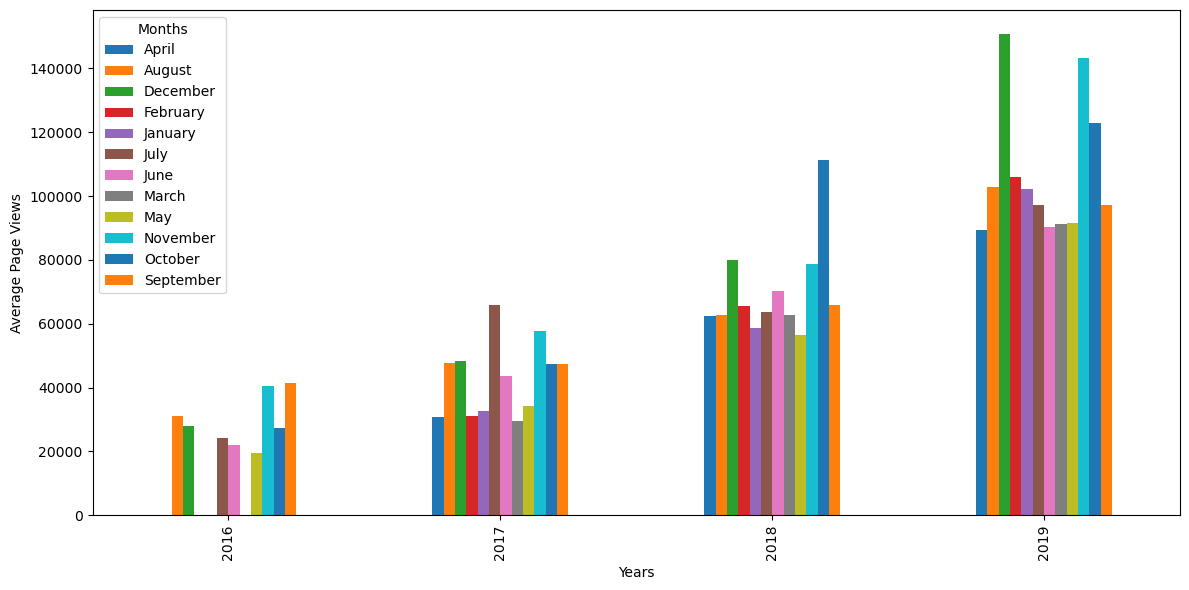

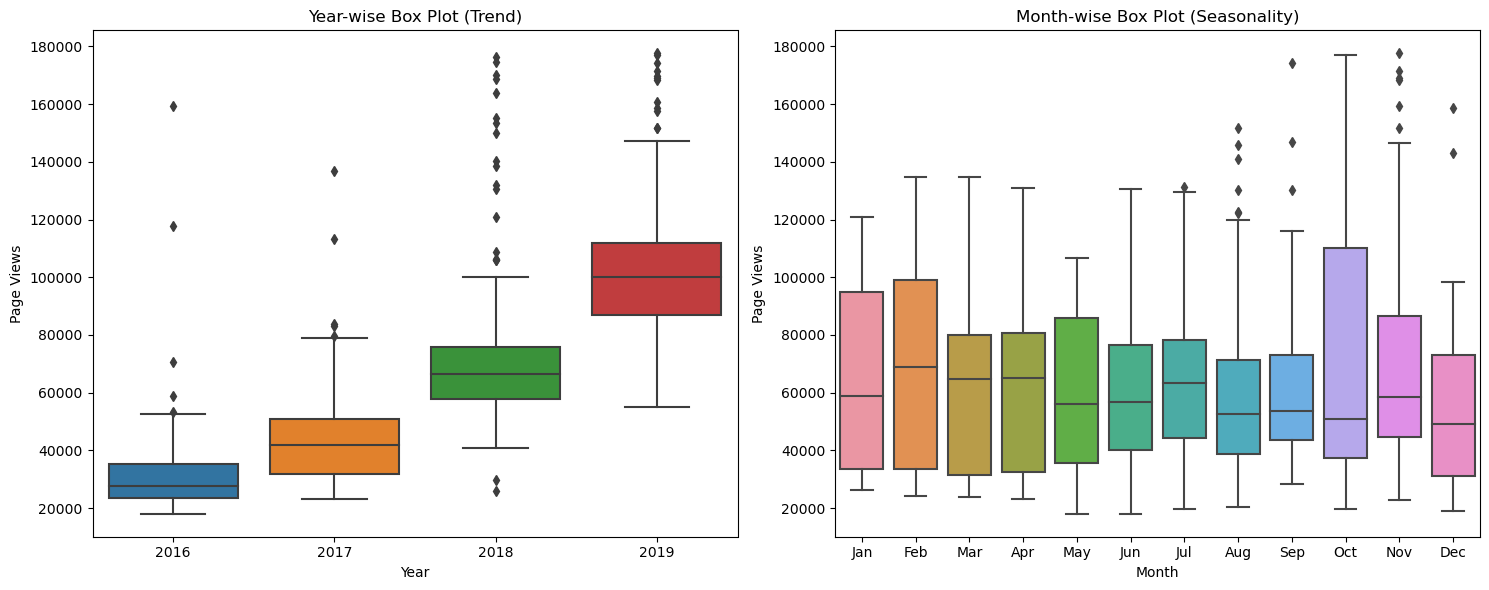

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("https://raw.githubusercontent.com/FreeCodeCamp/boilerplate-page-view-time-series-visualizer/main/fcc-forum-pageviews.csv", parse_dates=['date'], index_col='date')

# Clean data: remove top and bottom 2.5%
lower = df['value'].quantile(0.025)
upper = df['value'].quantile(0.975)
df_clean = df[(df['value'] >= lower) & (df['value'] <= upper)]

# Task 1: Line plot
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_clean.index, df_clean['value'], color='red', linewidth=1)
ax.set_title("Daily freeCodeCamp Forum Page Views 5/2016–12/2019")
ax.set_xlabel("Date")
ax.set_ylabel("Page Views")
plt.tight_layout()
plt.show()

# Task 2: Bar plot
df_bar = df_clean.copy()
df_bar['year'] = df_bar.index.year
df_bar['month'] = df_bar.index.month_name()

# Group and pivot
df_grouped = df_bar.groupby(['year', 'month'])['value'].mean().unstack()

# Plot
df_grouped.plot(kind='bar', figsize=(12, 6))
plt.xlabel("Years")
plt.ylabel("Average Page Views")
plt.legend(title="Months")
plt.tight_layout()
plt.show()

# Task 3: Box plots
df_box = df_clean.copy()
df_box.reset_index(inplace=True)
df_box['year'] = df_box['date'].dt.year
df_box['month'] = df_box['date'].dt.strftime('%b')
df_box['month_num'] = df_box['date'].dt.month
df_box = df_box.sort_values('month_num')

# Year-wise box plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(x='year', y='value', data=df_box, ax=axes[0])
axes[0].set_title("Year-wise Box Plot (Trend)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Page Views")

# Month-wise box plot
sns.boxplot(x='month', y='value', data=df_box, ax=axes[1])
axes[1].set_title("Month-wise Box Plot (Seasonality)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Page Views")

plt.tight_layout()
plt.show()
